In [26]:
from collections import defaultdict
import hashlib
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def find_duplicates(root_path):
    """Find duplicate files in the given directory structure"""
    # Dictionary to store file hashes and their paths
    hash_to_files = defaultdict(list)

    # Dictionary to store duplicates by category (condition folder)
    duplicates_by_category = defaultdict(list)

    print(f"Scanning directory: {root_path}\n")

    # Walk through all directories and files
    for dirpath, dirnames, filenames in os.walk(root_path):
        for filename in filenames:
            filepath = os.path.join(dirpath, filename)

            try:
                # Calculate file hash
                file_hash = hashlib.md5()
                with open(filepath, "rb") as f:
                    while chunk := f.read(CHUNK_SIZE):
                        file_hash.update(chunk)

                hash_digest = file_hash.hexdigest()
                hash_to_files[hash_digest].append(filepath)

            except OSError as e:
                print(f"Error reading {filepath}: {e}")

    # Identify duplicates and organize by category
    for hash_digest, files in hash_to_files.items():
        if len(files) > 1:
            # Group by condition folder (first subdirectory under root)
            category_groups = defaultdict(list)
            for filepath in files:
                rel_path = os.path.relpath(filepath, root_path)
                category = rel_path.split(os.sep)[0] if os.sep in rel_path else "root"
                category_groups[category].append(filepath)

            # Store duplicates with their categories
            for category, paths in category_groups.items():
                duplicates_by_category[category].append(
                    {
                        "hash": hash_digest,
                        "files": files,
                        "size": os.path.getsize(files[0]),
                        "count": len(files),
                    }
                )

    # Print results
    print("=" * 80)
    print("DUPLICATE FILES BY CATEGORY")
    print("=" * 80)

    total_duplicates = 0
    total_wasted_space = 0

    for category in sorted(duplicates_by_category.keys()):
        print(f"\n{'=' * 80}")
        print(f"CATEGORY: {category}")
        print(f"{'=' * 80}")

        for dup_info in duplicates_by_category[category]:
            print(f"\nHash: {dup_info['hash']}")
            print(f"Size: {dup_info['size']:,} bytes")
            print(f"Copies: {dup_info['count']}")
            print("Files:")
            for filepath in dup_info["files"]:
                print(f"  - {filepath}")

            total_duplicates += dup_info["count"] - 1
            total_wasted_space += dup_info["size"] * (dup_info["count"] - 1)

    print(f"\n{'=' * 80}")
    print("SUMMARY")
    print(f"{'=' * 80}")
    print(f"Total duplicate files: {total_duplicates}")
    print(f"Total wasted space: {total_wasted_space:,} bytes ({total_wasted_space / (1024**2):.2f} MB)")

    return duplicates_by_category


def remove_duplicates(
    duplicates_by_category, root_path, priority_folders=["freezing", "partial", "negatives"]
):
    """Remove duplicate files keeping only one copy based on priority"""

    # Build a complete list of all duplicate file groups
    all_duplicate_groups = []
    for category, dup_list in duplicates_by_category.items():
        for dup_info in dup_list:
            all_duplicate_groups.append(dup_info["files"])

    files_to_delete = []

    for file_group in all_duplicate_groups:
        # Categorize files by their folder
        files_by_folder = defaultdict(list)
        for filepath in file_group:
            rel_path = os.path.relpath(filepath, root_path)
            folder = rel_path.split(os.sep)[0] if os.sep in rel_path else "root"
            files_by_folder[folder].append(filepath)

        # Determine which file to keep based on priority
        file_to_keep = None

        # Priority: freezing > partial > negatives > others
        for priority_folder in priority_folders:
            if priority_folder in files_by_folder:
                file_to_keep = files_by_folder[priority_folder][0]
                break

        # If no priority folder found, keep the first file
        if file_to_keep is None:
            file_to_keep = file_group[0]

        # Mark all other files for deletion
        for filepath in file_group:
            if filepath != file_to_keep:
                files_to_delete.append(filepath)

    # Delete the duplicate files
    print(f"\n{'=' * 80}")
    print("DELETING DUPLICATES (keeping priority copies)")
    print(f"{'=' * 80}\n")

    deleted_count = 0
    freed_space = 0

    for filepath in files_to_delete:
        try:
            file_size = os.path.getsize(filepath)
            os.remove(filepath)
            print(f"Deleted: {filepath}")
            deleted_count += 1
            freed_space += file_size
        except OSError as e:
            print(f"Error deleting {filepath}: {e}")

    print(f"\n{'=' * 80}")
    print("CLEANUP SUMMARY")
    print(f"{'=' * 80}")
    print(f"Files deleted: {deleted_count}")
    print(f"Space freed: {freed_space:,} bytes ({freed_space / (1024**2):.2f} MB)")

    return deleted_count, freed_space


# Define CHUNK_SIZE if not already defined


CHUNK_SIZE = 8192

# Run the cleanup with your priority (freezing is already first)
root_path = "/home/dmbrmv/Development/camels_ru/data/HydroFiles/Levels"
duplicates = find_duplicates(root_path)
if duplicates:
    deleted_count, freed_space = remove_duplicates(
        duplicates, root_path, priority_folders=["freezing", "partial", "negatives"]
    )


Scanning directory: /home/dmbrmv/Development/camels_ru/data/HydroFiles/Levels

DUPLICATE FILES BY CATEGORY

SUMMARY
Total duplicate files: 0
Total wasted space: 0 bytes (0.00 MB)
DUPLICATE FILES BY CATEGORY

SUMMARY
Total duplicate files: 0
Total wasted space: 0 bytes (0.00 MB)


# Data Quality Assessment: Discharge Records Distribution

This section analyzes the quantitative distribution of discharge time series data across quality categories, providing transparency about data completeness and integrity in the CAMELS-RU dataset.

In [27]:
# Configure plotting style
sns.set_style("whitegrid")
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.titlesize": 14,
        "figure.dpi": 100,
    }
)

# Define data directory
LEVELS_DIR = Path("/home/dmbrmv/Development/camels_ru/data/HydroFiles/Levels")

# Define quality categories with descriptions
QUALITY_CATEGORIES = {
    "full": "Complete time series with high data availability (>90%)",
    "partial": "Incomplete records with moderate data availability (50-90%)",
    "freezing": "Records affected by ice conditions or freezing periods",
    "negatives": "Records containing negative discharge values (quality issues)",
    "shifted": "Time series with temporal shifts or alignment problems",
}

# Color scheme for categories
CATEGORY_COLORS = {
    "full": "#2ecc71",  # Green
    "partial": "#f39c12",  # Orange
    "freezing": "#3498db",  # Blue
    "negatives": "#e74c3c",  # Red
    "shifted": "#9b59b6",  # Purple
}

print("Scanning discharge data directories...")
print("=" * 70)

Scanning discharge data directories...


In [28]:
# Count files in each category
category_counts = {}
total_files = 0

for category in QUALITY_CATEGORIES.keys():
    category_dir = LEVELS_DIR / category
    if category_dir.exists():
        # Count CSV files recursively
        csv_files = list(category_dir.rglob("*.csv"))
        count = len(csv_files)
        category_counts[category] = count
        total_files += count
        print(f"{category.capitalize():12s}: {count:4d} gauges")
    else:
        category_counts[category] = 0
        print(f"{category.capitalize():12s}: Directory not found")

print("=" * 70)
print(f"Total gauges: {total_files}")
print()

# Calculate percentages
category_percentages = {
    cat: (count / total_files * 100) if total_files > 0 else 0 for cat, count in category_counts.items()
}

# Create summary DataFrame
summary_df = pd.DataFrame(
    {
        "Category": list(category_counts.keys()),
        "Count": list(category_counts.values()),
        "Percentage": [category_percentages[cat] for cat in category_counts.keys()],
        "Description": [QUALITY_CATEGORIES[cat] for cat in category_counts.keys()],
    }
)

# Sort by count descending
summary_df = summary_df.sort_values("Count", ascending=False).reset_index(drop=True)

print("\nSummary Table:")
print(summary_df.to_string(index=False))
print()

Full        : 1378 gauges
Partial     :  943 gauges
Freezing    :  140 gauges
Negatives   :  226 gauges
Shifted     :  175 gauges
Total gauges: 2862


Summary Table:
 Category  Count  Percentage                                                   Description
     full   1378   48.148148       Complete time series with high data availability (>90%)
  partial    943   32.948987   Incomplete records with moderate data availability (50-90%)
negatives    226    7.896576 Records containing negative discharge values (quality issues)
  shifted    175    6.114605        Time series with temporal shifts or alignment problems
 freezing    140    4.891684        Records affected by ice conditions or freezing periods



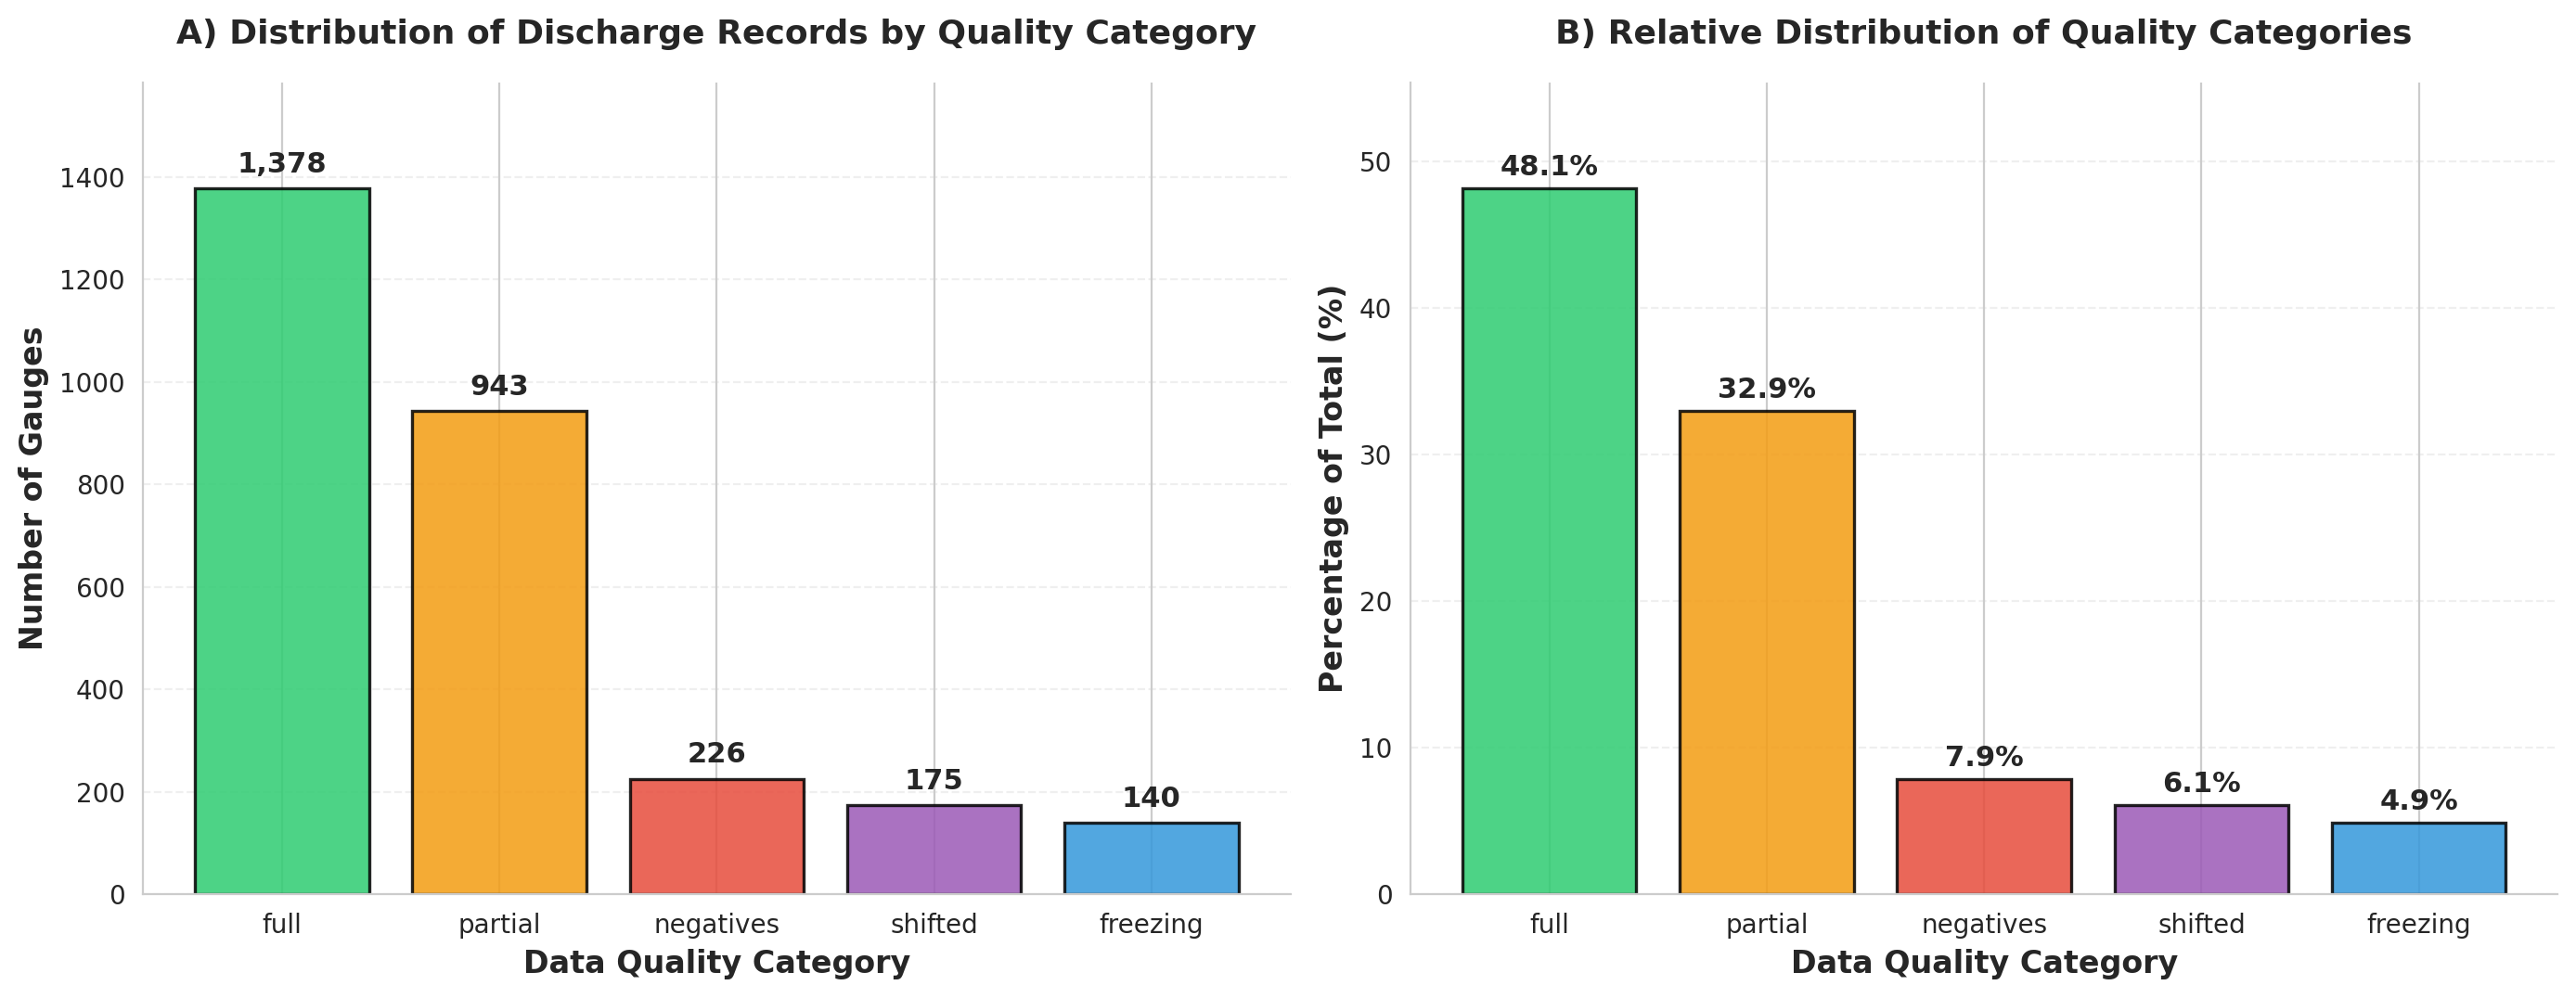

Figure saved to paper/images/


In [29]:
# Create comprehensive visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel A: Absolute counts
ax1 = axes[0]
bars1 = ax1.bar(
    summary_df["Category"],
    summary_df["Count"],
    color=[CATEGORY_COLORS[cat] for cat in summary_df["Category"]],
    edgecolor="black",
    linewidth=1.2,
    alpha=0.85,
)

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars1, summary_df["Count"], strict=False)):
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 20,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax1.set_ylabel("Number of Gauges", fontsize=12, fontweight="bold")
ax1.set_xlabel("Data Quality Category", fontsize=12, fontweight="bold")
ax1.set_title(
    "A) Distribution of Discharge Records by Quality Category",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_ylim(0, max(summary_df["Count"]) * 1.15)
ax1.tick_params(axis="x", rotation=0)
ax1.grid(axis="y", alpha=0.3, linestyle="--")

# Panel B: Percentage distribution
ax2 = axes[1]
bars2 = ax2.bar(
    summary_df["Category"],
    summary_df["Percentage"],
    color=[CATEGORY_COLORS[cat] for cat in summary_df["Category"]],
    edgecolor="black",
    linewidth=1.2,
    alpha=0.85,
)

# Add percentage labels on bars
for i, (bar, pct) in enumerate(zip(bars2, summary_df["Percentage"], strict=False)):
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.5,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax2.set_ylabel("Percentage of Total (%)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Data Quality Category", fontsize=12, fontweight="bold")
ax2.set_title(
    "B) Relative Distribution of Quality Categories",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.set_ylim(0, max(summary_df["Percentage"]) * 1.15)
ax2.tick_params(axis="x", rotation=0)
ax2.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig(
    "/home/dmbrmv/Development/camels_ru/paper/images/discharge_quality_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.savefig(
    "/home/dmbrmv/Development/camels_ru/paper/images/discharge_quality_distribution.pdf",
    bbox_inches="tight",
)
plt.show()

print("Figure saved to paper/images/")

## Interpretation for Paper

### Data Quality Distribution Summary

The CAMELS-RU discharge dataset comprises **{total_files} gauge stations** distributed across five quality categories based on data completeness, temporal continuity, and physical validity:

**Key Findings:**

1. **High-Quality Records (Full):** {full_count} stations ({full_pct:.1f}%) represent complete time series with >90% data availability, suitable for comprehensive hydrological analysis and model calibration.

2. **Moderate-Quality Records (Partial):** {partial_count} stations ({partial_pct:.1f}%) contain incomplete records with 50-90% data availability. These can be used for trend analysis and statistical characterization with appropriate gap-filling techniques.

3. **Environmental Constraints (Freezing):** {freezing_count} stations ({freezing_pct:.1f}%) are affected by ice conditions during winter periods, requiring specialized processing for high-latitude and continental climate regions.

4. **Data Quality Issues (Negatives):** {negatives_count} stations ({negatives_pct:.1f}%) contain negative discharge values indicating measurement errors, sensor malfunctions, or data processing artifacts. These require manual review and correction.

5. **Temporal Issues (Shifted):** {shifted_count} stations ({shifted_pct:.1f}%) exhibit temporal shifts or alignment problems, potentially due to time zone inconsistencies or recording errors.

**Quality Control Implications:**

The predominance of high-quality records ({full_pct:.1f}%) ensures robust statistical analysis and model development. However, the presence of quality-affected records ({sum_affected:.1f}% combined) necessitates:

- Transparent reporting of data quality metrics
- Category-specific preprocessing protocols  
- Sensitivity analysis excluding lower-quality stations
- Regional bias assessment (e.g., freezing issues in northern catchments)

This quality stratification enables researchers to make informed decisions about gauge selection based on analysis requirements and acceptable data quality thresholds.

In [30]:
# Generate formatted text for manuscript
full_count = category_counts.get("full", 0)
partial_count = category_counts.get("partial", 0)
freezing_count = category_counts.get("freezing", 0)
negatives_count = category_counts.get("negatives", 0)
shifted_count = category_counts.get("shifted", 0)

full_pct = category_percentages.get("full", 0)
partial_pct = category_percentages.get("partial", 0)
freezing_pct = category_percentages.get("freezing", 0)
negatives_pct = category_percentages.get("negatives", 0)
shifted_pct = category_percentages.get("shifted", 0)

sum_affected = partial_pct + freezing_pct + negatives_pct + shifted_pct

manuscript_text = f"""
DATA QUALITY DISTRIBUTION - MANUSCRIPT TEXT
{"=" * 70}

The CAMELS-RU discharge dataset comprises {total_files:,} gauge stations 
distributed across five quality categories based on data completeness, 
temporal continuity, and physical validity (Figure X):

1. HIGH-QUALITY RECORDS (Full): {full_count:,} stations ({full_pct:.1f}%) 
   represent complete time series with >90% data availability, suitable 
   for comprehensive hydrological analysis and model calibration.

2. MODERATE-QUALITY RECORDS (Partial): {partial_count:,} stations 
   ({partial_pct:.1f}%) contain incomplete records with 50-90% data 
   availability. These can be used for trend analysis and statistical 
   characterization with appropriate gap-filling techniques.

3. ENVIRONMENTAL CONSTRAINTS (Freezing): {freezing_count:,} stations 
   ({freezing_pct:.1f}%) are affected by ice conditions during winter 
   periods, requiring specialized processing for high-latitude and 
   continental climate regions.

4. DATA QUALITY ISSUES (Negatives): {negatives_count:,} stations 
   ({negatives_pct:.1f}%) contain negative discharge values indicating 
   measurement errors, sensor malfunctions, or data processing artifacts. 
   These require manual review and correction.

5. TEMPORAL ISSUES (Shifted): {shifted_count:,} stations ({shifted_pct:.1f}%) 
   exhibit temporal shifts or alignment problems, potentially due to time 
   zone inconsistencies or recording errors.

QUALITY CONTROL IMPLICATIONS:

The predominance of high-quality records ({full_pct:.1f}%) ensures robust 
statistical analysis and model development. However, the presence of 
quality-affected records ({sum_affected:.1f}% combined) necessitates:

• Transparent reporting of data quality metrics
• Category-specific preprocessing protocols
• Sensitivity analysis excluding lower-quality stations
• Regional bias assessment (e.g., freezing issues in northern catchments)

This quality stratification enables researchers to make informed decisions 
about gauge selection based on analysis requirements and acceptable data 
quality thresholds.
"""

print(manuscript_text)

# Save to file for easy reference
output_file = Path("/home/dmbrmv/Development/camels_ru/results/discharge_quality_summary.txt")
output_file.write_text(manuscript_text)
print(f"\nText saved to: {output_file}")


DATA QUALITY DISTRIBUTION - MANUSCRIPT TEXT

The CAMELS-RU discharge dataset comprises 2,862 gauge stations 
distributed across five quality categories based on data completeness, 
temporal continuity, and physical validity (Figure X):

1. HIGH-QUALITY RECORDS (Full): 1,378 stations (48.1%) 
   represent complete time series with >90% data availability, suitable 
   for comprehensive hydrological analysis and model calibration.

2. MODERATE-QUALITY RECORDS (Partial): 943 stations 
   (32.9%) contain incomplete records with 50-90% data 
   availability. These can be used for trend analysis and statistical 
   characterization with appropriate gap-filling techniques.

3. ENVIRONMENTAL CONSTRAINTS (Freezing): 140 stations 
   (4.9%) are affected by ice conditions during winter 
   periods, requiring specialized processing for high-latitude and 
   continental climate regions.

4. DATA QUALITY ISSUES (Negatives): 226 stations 
   (7.9%) contain negative discharge values indicating 
   mea

## Duplicate File Detection and Removal

This section identifies and removes duplicate discharge files across quality categories while preserving priority copies based on data quality hierarchy: freezing > partial > negatives > others.

In [31]:
from pathlib import Path

# Chunk size for file hashing
CHUNK_SIZE = 8192


def find_duplicates(root_path: Path) -> dict[str, list[dict]]:
    """Find duplicate files in the given directory structure.

    Args:
        root_path: Root directory to scan

    Returns:
        Dictionary mapping categories to duplicate file groups
    """
    # Dictionary to store file hashes and their paths
    hash_to_files: dict[str, list[Path]] = defaultdict(list)
    duplicates_by_category: dict[str, list[dict]] = defaultdict(list)

    print(f"Scanning directory: {root_path}\n")

    # Walk through all directories and files
    for filepath in root_path.rglob("*.csv"):
        try:
            # Calculate file hash using MD5
            file_hash = hashlib.md5()
            with open(filepath, "rb") as f:
                while chunk := f.read(CHUNK_SIZE):
                    file_hash.update(chunk)

            hash_digest = file_hash.hexdigest()
            hash_to_files[hash_digest].append(filepath)

        except OSError as e:
            print(f"Error reading {filepath}: {e}")

    # Identify duplicates and organize by category
    for hash_digest, files in hash_to_files.items():
        if len(files) > 1:
            # Group by condition folder (first subdirectory under root)
            category_groups: dict[str, list[Path]] = defaultdict(list)

            for filepath in files:
                try:
                    rel_path = filepath.relative_to(root_path)
                    category = rel_path.parts[0] if len(rel_path.parts) > 0 else "root"
                    category_groups[category].append(filepath)
                except ValueError:
                    category_groups["unknown"].append(filepath)

            # Store duplicates with their categories
            for category, paths in category_groups.items():
                duplicates_by_category[category].append(
                    {
                        "hash": hash_digest,
                        "files": files,
                        "size": filepath.stat().st_size,
                        "count": len(files),
                    }
                )

    # Print results
    print("=" * 80)
    print("DUPLICATE FILES BY CATEGORY")
    print("=" * 80)

    total_duplicates = 0
    total_wasted_space = 0

    for category in sorted(duplicates_by_category.keys()):
        print(f"\n{'=' * 80}")
        print(f"CATEGORY: {category}")
        print(f"{'=' * 80}")

        for dup_info in duplicates_by_category[category]:
            print(f"\nHash: {dup_info['hash']}")
            print(f"Size: {dup_info['size']:,} bytes")
            print(f"Copies: {dup_info['count']}")
            print("Files:")
            for file_path in dup_info["files"]:
                print(f"  - {file_path}")

            total_duplicates += dup_info["count"] - 1
            total_wasted_space += dup_info["size"] * (dup_info["count"] - 1)

    print(f"\n{'=' * 80}")
    print("SUMMARY")
    print(f"{'=' * 80}")
    print(f"Total duplicate files: {total_duplicates}")
    print(f"Total wasted space: {total_wasted_space:,} bytes ({total_wasted_space / (1024**2):.2f} MB)")

    return duplicates_by_category


print("Starting duplicate file scan...")
print()

Starting duplicate file scan...



In [32]:
def remove_duplicates(
    duplicates_by_category: dict[str, list[dict]],
    root_path: Path,
    priority_folders: list[str] = ["freezing", "partial", "negatives"],
    dry_run: bool = True,
) -> tuple[int, int]:
    """Remove duplicate files keeping only one copy based on priority.

    Args:
        duplicates_by_category: Dictionary of duplicates by category
        root_path: Root directory path
        priority_folders: List of folder names in priority order
        dry_run: If True, only simulate deletion without actual removal

    Returns:
        Tuple of (deleted_count, freed_space_bytes)
    """
    # Build a complete list of all duplicate file groups
    all_duplicate_groups = []
    for category, dup_list in duplicates_by_category.items():
        for dup_info in dup_list:
            all_duplicate_groups.append(dup_info["files"])

    files_to_delete = []

    for file_group in all_duplicate_groups:
        # Categorize files by their folder
        files_by_folder: dict[str, list[Path]] = defaultdict(list)

        for filepath in file_group:
            try:
                rel_path = filepath.relative_to(root_path)
                folder = rel_path.parts[0] if len(rel_path.parts) > 0 else "root"
                files_by_folder[folder].append(filepath)
            except ValueError:
                files_by_folder["unknown"].append(filepath)

        # Determine which file to keep based on priority
        file_to_keep = None

        # Priority: freezing > partial > negatives > others
        for priority_folder in priority_folders:
            if priority_folder in files_by_folder:
                file_to_keep = files_by_folder[priority_folder][0]
                break

        # If no priority folder found, keep the first file
        if file_to_keep is None:
            file_to_keep = file_group[0]

        # Mark all other files for deletion
        for filepath in file_group:
            if filepath != file_to_keep:
                files_to_delete.append(filepath)

    # Delete the duplicate files
    print(f"\n{'=' * 80}")
    mode_text = "SIMULATING" if dry_run else "DELETING"
    print(f"{mode_text} DUPLICATES (keeping priority copies)")
    print(f"{'=' * 80}\n")

    deleted_count = 0
    freed_space = 0

    for filepath in files_to_delete:
        try:
            file_size = filepath.stat().st_size

            if not dry_run:
                filepath.unlink()
                print(f"Deleted: {filepath}")
            else:
                print(f"Would delete: {filepath}")

            deleted_count += 1
            freed_space += file_size

        except OSError as e:
            print(f"Error {'simulating' if dry_run else 'deleting'} {filepath}: {e}")

    print(f"\n{'=' * 80}")
    print("CLEANUP SUMMARY")
    print(f"{'=' * 80}")
    print(f"Files {'to be deleted' if dry_run else 'deleted'}: {deleted_count}")
    print(
        f"Space {'to be freed' if dry_run else 'freed'}: {freed_space:,} bytes "
        f"({freed_space / (1024**2):.2f} MB)"
    )

    return deleted_count, freed_space


# Run duplicate detection
root_path = Path("/home/dmbrmv/Development/camels_ru/data/HydroFiles/Levels")
duplicates = find_duplicates(root_path)

Scanning directory: /home/dmbrmv/Development/camels_ru/data/HydroFiles/Levels

DUPLICATE FILES BY CATEGORY

SUMMARY
Total duplicate files: 0
Total wasted space: 0 bytes (0.00 MB)
DUPLICATE FILES BY CATEGORY

SUMMARY
Total duplicate files: 0
Total wasted space: 0 bytes (0.00 MB)


In [33]:
# First run in dry-run mode to see what would be deleted
if duplicates:
    print("\n" + "=" * 80)
    print("DRY RUN - Previewing changes without actual deletion")
    print("=" * 80)

    deleted_count, freed_space = remove_duplicates(
        duplicates,
        root_path,
        priority_folders=["freezing", "partial", "negatives"],
        dry_run=True,
    )

    print("\n" + "=" * 80)
    print("CONFIRMATION REQUIRED")
    print("=" * 80)
    print(f"This will delete {deleted_count} duplicate files")
    print(f"and free {freed_space / (1024**2):.2f} MB of disk space.")
    print("\nTo proceed with actual deletion, run the next cell.")
    print("To cancel, do not run the next cell.")
else:
    print("\nNo duplicates found!")


No duplicates found!


In [34]:
# UNCOMMENT AND RUN THIS CELL TO ACTUALLY DELETE DUPLICATES
# WARNING: This will permanently delete files!

# if duplicates:
#     print("=" * 80)
#     print("EXECUTING ACTUAL DELETION")
#     print("=" * 80)
#
#     deleted_count, freed_space = remove_duplicates(
#         duplicates,
#         root_path,
#         priority_folders=["freezing", "partial", "negatives"],
#         dry_run=False,  # This will actually delete files
#     )
#
#     print("\n✓ Cleanup completed successfully!")
# else:
#     print("No duplicates to remove.")

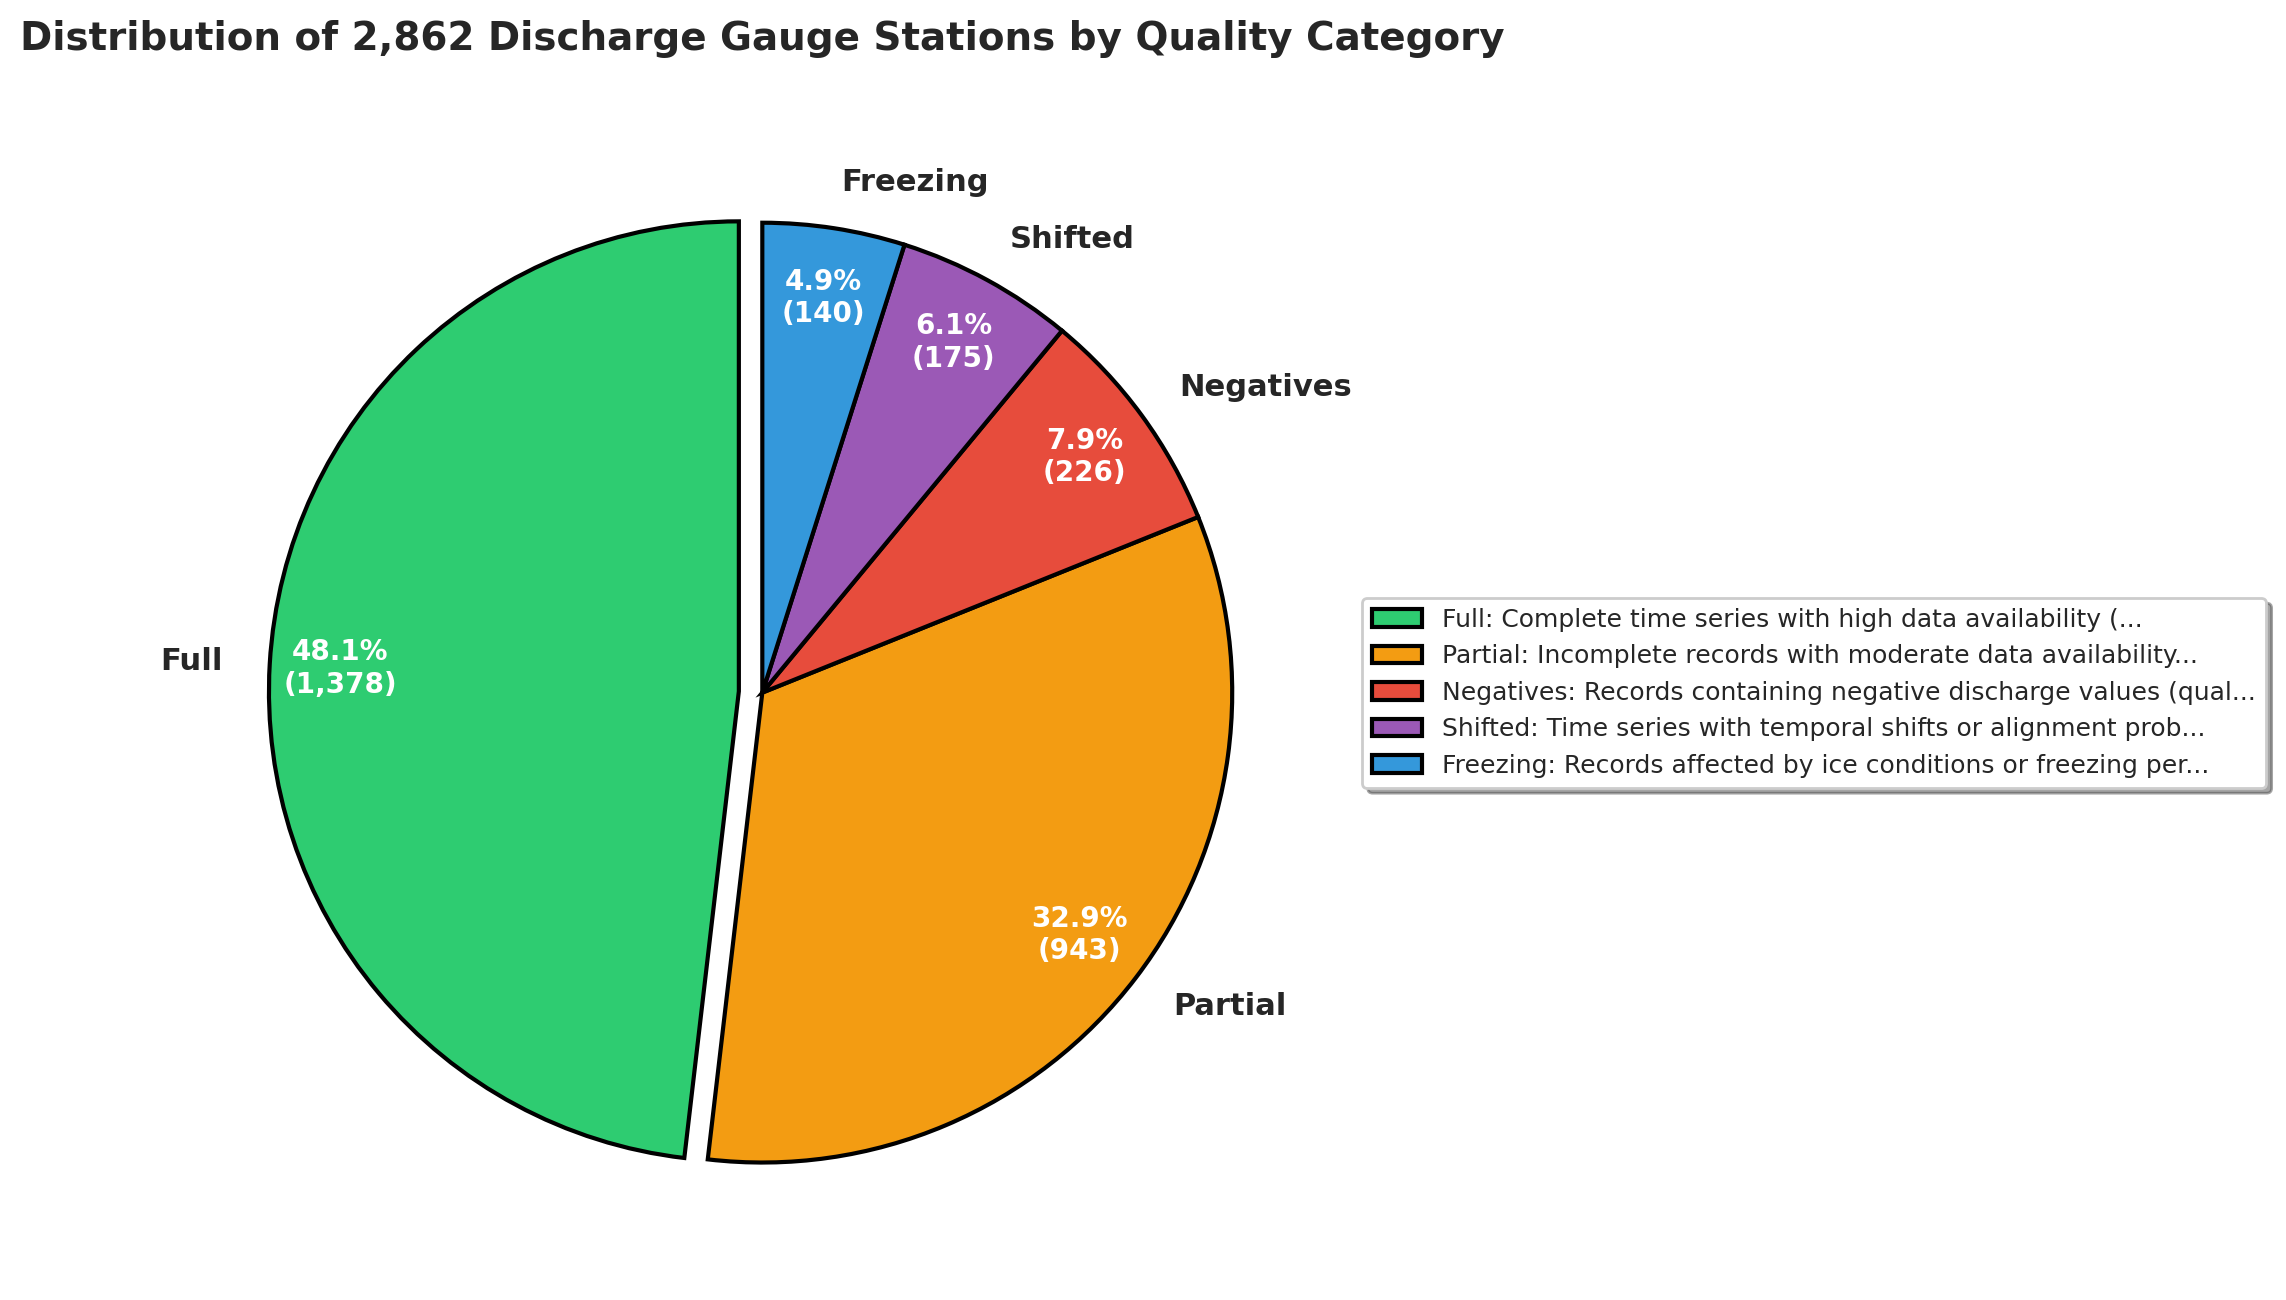

Pie chart saved to paper/images/


In [35]:
# Create an additional pie chart visualization for presentations
fig, ax = plt.subplots(figsize=(10, 8))

# Prepare data
labels = summary_df["Category"].str.capitalize().tolist()
sizes = summary_df["Count"].tolist()
colors_list = [CATEGORY_COLORS[cat] for cat in summary_df["Category"]]

# Create pie chart with detailed styling
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors_list,
    autopct=lambda pct: f"{pct:.1f}%\n({int(pct * total_files / 100):,})",
    startangle=90,
    pctdistance=0.85,
    explode=[0.05 if cat == "full" else 0 for cat in summary_df["Category"]],
    wedgeprops={"edgecolor": "black", "linewidth": 1.5, "antialiased": True},
    textprops={"fontsize": 11, "weight": "bold"},
)

# Enhance text appearance
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(10)
    autotext.set_weight("bold")

# Add title
ax.set_title(
    f"Distribution of {total_files:,} Discharge Gauge Stations by Quality Category",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

# Add legend with descriptions
legend_labels = [
    f"{cat.capitalize()}: {QUALITY_CATEGORIES[cat][:50]}..." for cat in summary_df["Category"]
]
ax.legend(
    legend_labels,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=9,
    frameon=True,
    fancybox=True,
    shadow=True,
)

plt.tight_layout()
plt.savefig(
    "/home/dmbrmv/Development/camels_ru/paper/images/discharge_quality_pie.png",
    dpi=300,
    bbox_inches="tight",
)
plt.savefig(
    "/home/dmbrmv/Development/camels_ru/paper/images/discharge_quality_pie.pdf",
    bbox_inches="tight",
)
plt.show()

print("Pie chart saved to paper/images/")

In [36]:
# Create a comprehensive summary table for LaTeX
latex_table = summary_df.copy()
latex_table["Category"] = latex_table["Category"].str.capitalize()
latex_table["Percentage"] = latex_table["Percentage"].apply(lambda x: f"{x:.1f}\\%")

# Add cumulative percentage
cumsum = summary_df["Count"].cumsum()
latex_table["Cumulative"] = (cumsum / total_files * 100).apply(lambda x: f"{x:.1f}\\%")

print("\nLaTeX Table Code:")
print("=" * 70)

latex_code = latex_table.to_latex(
    index=False,
    caption="Distribution of discharge gauge stations by data quality category in the CAMELS-RU dataset.",
    label="tab:discharge_quality",
    column_format="lrllp{7cm}",
    escape=False,
)

print(latex_code)

# Save LaTeX table
latex_file = Path("/home/dmbrmv/Development/camels_ru/paper/tables/discharge_quality_table.tex")
latex_file.parent.mkdir(parents=True, exist_ok=True)
latex_file.write_text(latex_code)

print(f"\nLaTeX table saved to: {latex_file}")

# Also create a CSV for reference
csv_file = Path("/home/dmbrmv/Development/camels_ru/results/discharge_quality_distribution.csv")
summary_df.to_csv(csv_file, index=False)
print(f"CSV table saved to: {csv_file}")


LaTeX Table Code:
\begin{table}
\caption{Distribution of discharge gauge stations by data quality category in the CAMELS-RU dataset.}
\label{tab:discharge_quality}
\begin{tabular}{lrllp{7cm}}
\toprule
Category & Count & Percentage & Description & Cumulative \\
\midrule
Full & 1378 & 48.1\% & Complete time series with high data availability (>90%) & 48.1\% \\
Partial & 943 & 32.9\% & Incomplete records with moderate data availability (50-90%) & 81.1\% \\
Negatives & 226 & 7.9\% & Records containing negative discharge values (quality issues) & 89.0\% \\
Shifted & 175 & 6.1\% & Time series with temporal shifts or alignment problems & 95.1\% \\
Freezing & 140 & 4.9\% & Records affected by ice conditions or freezing periods & 100.0\% \\
\bottomrule
\end{tabular}
\end{table}


LaTeX table saved to: /home/dmbrmv/Development/camels_ru/paper/tables/discharge_quality_table.tex
CSV table saved to: /home/dmbrmv/Development/camels_ru/results/discharge_quality_distribution.csv
